<a href="https://colab.research.google.com/github/karanveer-sharma/pythontraining_with_ai/blob/main/classdata_(1)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
df = pd.read_csv("assignmnet.xlsx - Sheet1.csv")
df.head(5)

,Sort by first name,Yesterday,26-Feb,24-Feb,23-Feb,No due date,19-Feb,22-Feb,17-Feb,16-Feb,12-Feb,11-Feb,11-Feb.1,11-Feb.2,8-Feb,7-Feb,5-Feb,3-Feb
0,NaN,Capstone Project: Real-World Health Risk Class...,Assignment 3: Decision Tree,Assignment 2: Logistic Regression,Assignment 1: Linear Regression,Prcatice for Data Preprocessing and Data Visua...,Assignment 6: Student Data Analysis,Mini Project :- Data Preprocessing and Visuali...,Assignment 3: Scaling and PCA,Assignment 2: Seaborn Library,Assignment 1: Matplotlib,Assginment 5: Advanced Pandas,Assigenment 4: Intermediate Level (Online Reta...,Assignment 3: Beginner Level - Titanic Dataset,Capstone Project,Assignment 2: Data Wrangling,Assignment 1: Pandas Basics,User & Group Management
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Class average,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Aarush,Missing,Turned in,Turned in,Missing,Assigned,Turned in,Turned in,Turned in,Turned in,Turned inDone late,Turned in,Turned in,Turned in,Turned in,Missing,Turned in,Turned in
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Sort by first name  46 non-null     object
 1   Yesterday           46 non-null     object
 2   26-Feb              46 non-null     object
 3   24-Feb              46 non-null     object
 4   23-Feb              46 non-null     object
 5   No due date         46 non-null     object
 6   19-Feb              46 non-null     object
 7   22-Feb              46 non-null     object
 8   17-Feb              46 non-null     object
 9   16-Feb              46 non-null     object
 10  12-Feb              46 non-null     object
 11  11-Feb              46 non-null     object
 12  11-Feb.1            46 non-null     object
 13  11-Feb.2            46 non-null     object
 14  8-Feb               46 non-null     object
 15  7-Feb               46 non-null     object
 16  5-Feb               46 non-n

In [ ]:
df.shape

(64, 18)

In [ ]:
df.describe()

,Sort by first name,Yesterday,26-Feb,24-Feb,23-Feb,No due date,19-Feb,22-Feb,17-Feb,16-Feb,12-Feb,11-Feb,11-Feb.1,11-Feb.2,8-Feb,7-Feb,5-Feb,3-Feb
count,46,46,46,46,46,46,46,46,46,46,46,46,46,46,46,46,46,46
unique,44,4,3,4,4,3,3,3,3,3,4,4,3,4,4,4,3,4
top,Abhinav Garg,Turned in,Turned in,Turned in,Turned in,Assigned,Turned in,Turned in,Turned in,Turned in,Turned in,Turned in,Turned in,Turned in,Turned in,Turned in,Turned in,Turned in
freq,2,33,39,28,35,31,33,34,29,36,34,37,35,41,37,32,40,27


In [ ]:
df.isnull().sum()

,0
Sort by first name,18
Yesterday,18
26-Feb,18
24-Feb,18
23-Feb,18
No due date,18
19-Feb,18
22-Feb,18
17-Feb,18
16-Feb,18


In [ ]:
df.columns = df.columns.str.strip()
df.rename(columns={df.columns[0]: "Name"}, inplace=True)


In [ ]:
df.fillna("Not Submitted", inplace=True)
df.drop_duplicates(inplace=True)
df["Name"] = df["Name"].astype(str)


In [ ]:
df.replace({
    "Turned inDone late": "Turned in Late",
    "Turned inDone Late": "Turned in Late",
    "Missing": "Not Submitted",
    "Assigned": "Pending"
}, inplace=True)


In [ ]:
valid_cols = ["Name","3-Feb","5-Feb","7-Feb","8-Feb","11-Feb","12-Feb","16-Feb","17-Feb",
              "19-Feb","22-Feb","23-Feb","24-Feb","26-Feb","Yesterday","No due date"]


In [ ]:
valid_cols = [col for col in valid_cols if col in df.columns]
df = df[valid_cols]


In [ ]:
df["Total_Submitted"] = (df == "Turned in").sum(axis=1)
df["Total_Late"] = (df == "Turned in Late").sum(axis=1)
df["Total_Missing"] = (df == "Not Submitted").sum(axis=1)
df["Total_Pending"] = (df == "Pending").sum(axis=1)


In [ ]:
completed_all = df[(df["Total_Missing"]==0) & (df["Total_Pending"]==0)]
on_time = df[(df["Total_Late"]==0) & (df["Total_Missing"]==0)]
most_turned_in = df.loc[df["Total_Submitted"].idxmax()]
most_uncomplete = df.loc[df["Total_Missing"].idxmax()]
pending_students = df[df["Total_Pending"]>0]


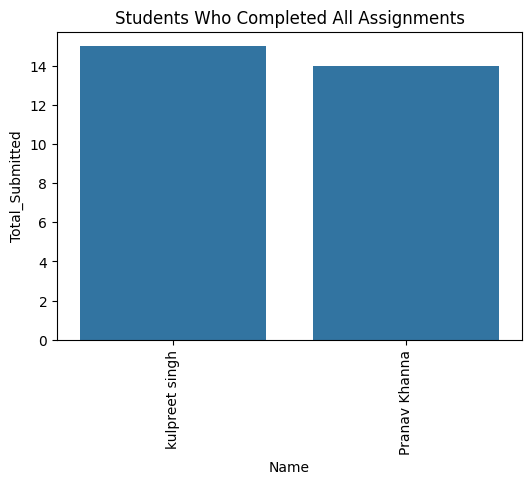

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x="Name", y="Total_Submitted", data=completed_all)
plt.xticks(rotation=90)
plt.title("Students Who Completed All Assignments")
plt.show()


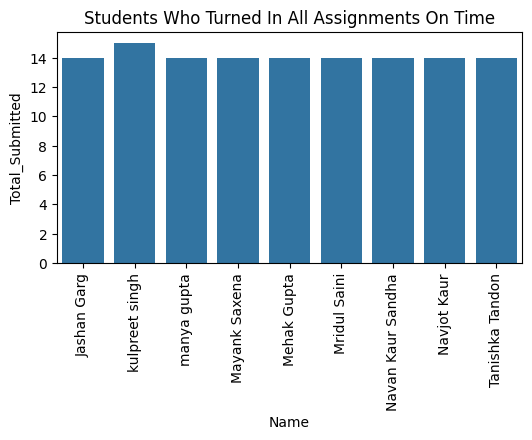

In [ ]:
plt.figure(figsize=(6,3))
sns.barplot(x="Name", y="Total_Submitted", data=on_time)
plt.xticks(rotation=90)
plt.title("Students Who Turned In All Assignments On Time")
plt.show()


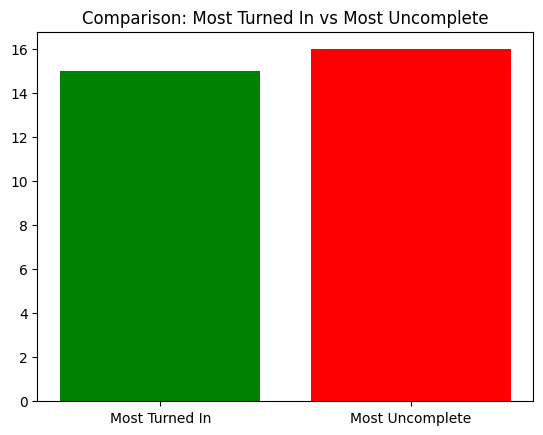

In [ ]:
labels = ["Most Turned In", "Most Uncomplete"]
values = [most_turned_in["Total_Submitted"], most_uncomplete["Total_Missing"]]

plt.bar(labels, values, color=["green","red"])
plt.title("Comparison: Most Turned In vs Most Uncomplete")
plt.show()


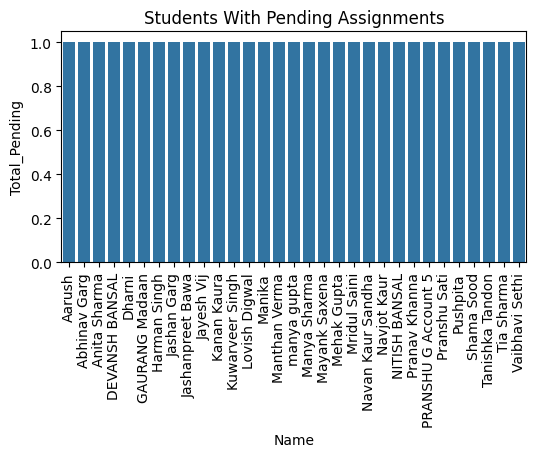

In [ ]:
plt.figure(figsize=(6,3))
sns.barplot(x="Name", y="Total_Pending", data=pending_students)
plt.xticks(rotation=90)
plt.title("Students With Pending Assignments")
plt.show()


In [ ]:
status_map = df.replace({
    "Turned in": 1,
    "Turned in Late": 0.5,
    "Not Submitted": 0,
    "Pending": -1
})

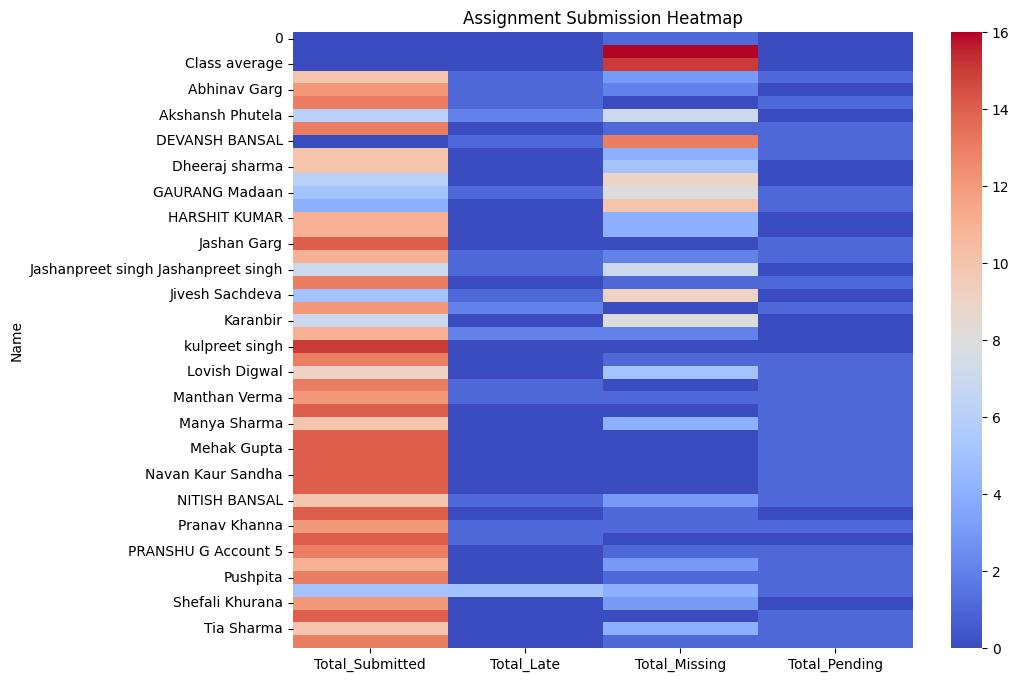

In [ ]:
heatmap_data = status_map.set_index("Name").select_dtypes(include=["number"])

plt.figure(figsize=(10,8))
sns.heatmap(heatmap_data, cmap="coolwarm", cbar=True)
plt.title("Assignment Submission Heatmap")
plt.show()

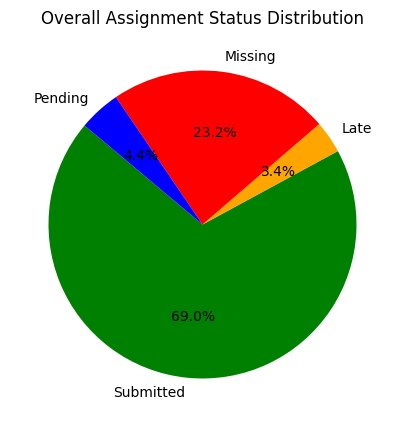

In [ ]:

status_counts = {
    "Submitted": (df == "Turned in").sum().sum(),
    "Late": (df == "Turned in Late").sum().sum(),
    "Missing": (df == "Not Submitted").sum().sum(),
    "Pending": (df == "Pending").sum().sum()
}

plt.figure(figsize=(5,5))
plt.pie(status_counts.values(), labels=status_counts.keys(), autopct='%1.1f%%', startangle=140, colors=["green","orange","red","blue"])
plt.title("Overall Assignment Status Distribution")
plt.show()

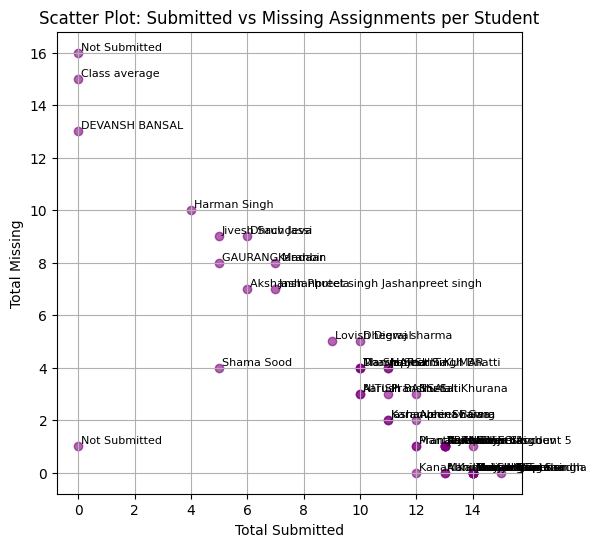

In [ ]:
# Scatter plot: Submitted vs Missing
plt.figure(figsize=(6,6))
plt.scatter(df["Total_Submitted"], df["Total_Missing"], c="purple", alpha=0.6)

for i, name in enumerate(df["Name"]):
    plt.text(df["Total_Submitted"].iloc[i]+0.1, df["Total_Missing"].iloc[i]+0.1, name, fontsize=8)

plt.xlabel("Total Submitted")
plt.ylabel("Total Missing")
plt.title("Scatter Plot: Submitted vs Missing Assignments per Student")
plt.grid(True)
plt.show()

In [ ]:
# Count each status per student
df["TurnedIn_Count"] = (df == "Turned in").sum(axis=1)
df["Pending_Count"] = (df == "Pending").sum(axis=1)
df["Late_Count"] = (df == "Turned in Late").sum(axis=1)
df["Missing_Count"] = (df == "Not Submitted").sum(axis=1)

# Keep only relevant columns for plotting
student_status = df[["Name","TurnedIn_Count","Pending_Count","Late_Count","Missing_Count"]]

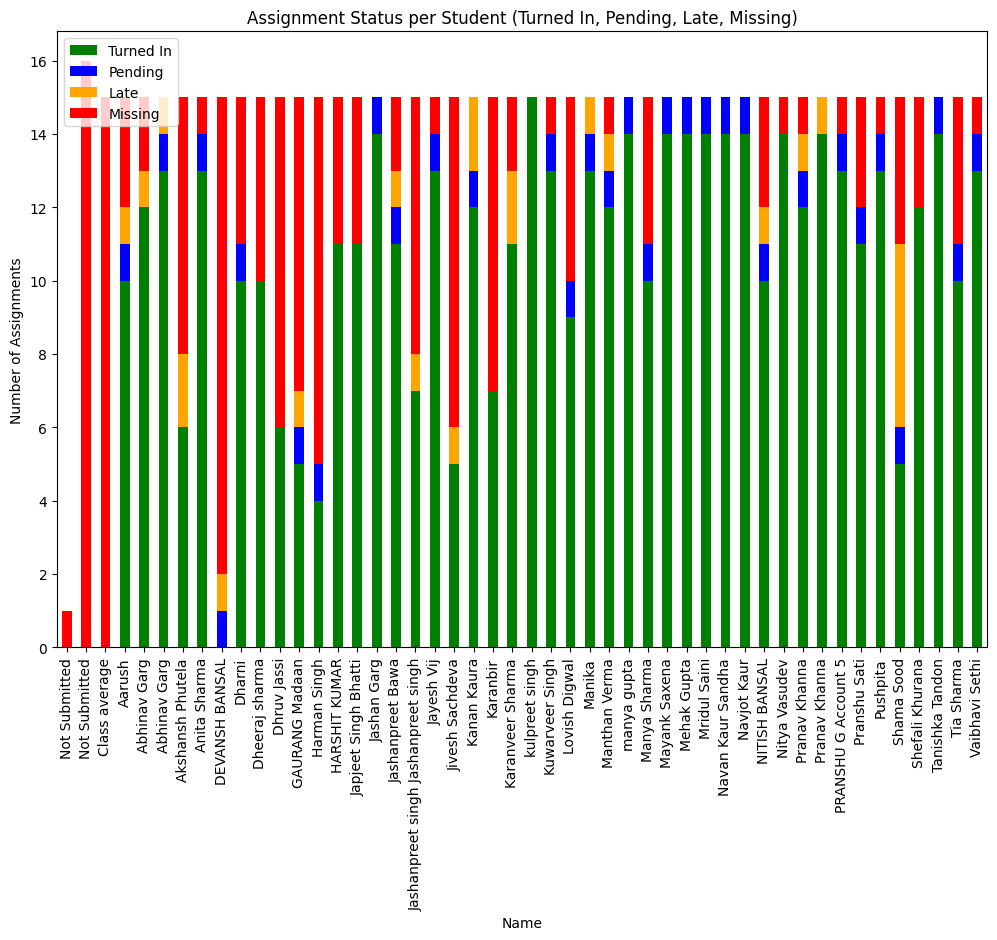

In [ ]:
# Stacked bar chart for all students
student_status.set_index("Name").plot(
    kind="bar", stacked=True, figsize=(12,8),
    color=["green","blue","orange","red"]
)

plt.xticks(rotation=90)
plt.ylabel("Number of Assignments")
plt.title("Assignment Status per Student (Turned In, Pending, Late, Missing)")
plt.legend(["Turned In","Pending","Late","Missing"])
plt.show()

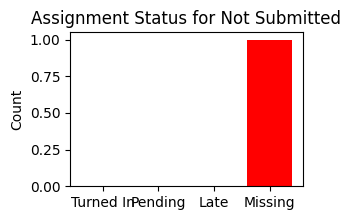

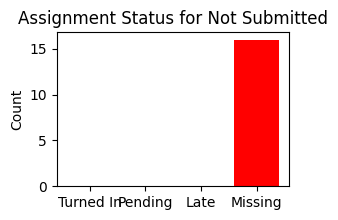

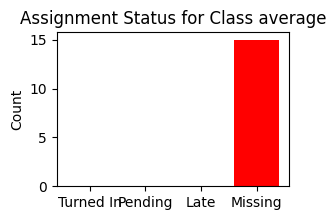

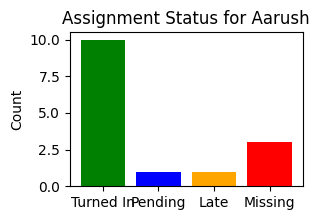

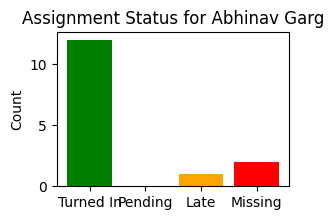

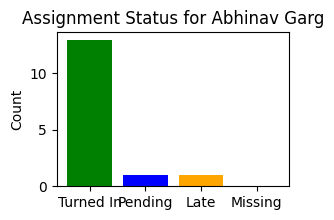

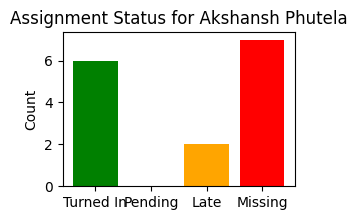

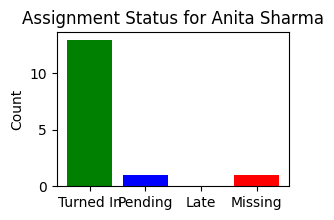

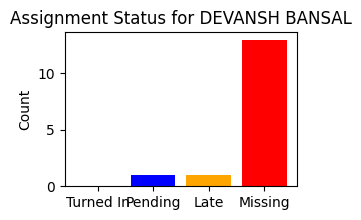

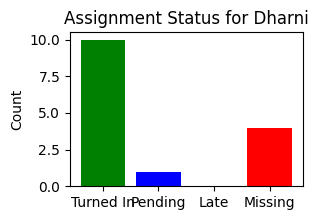

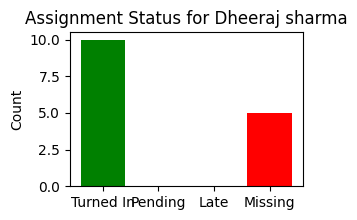

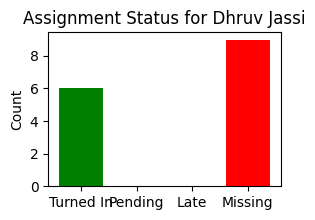

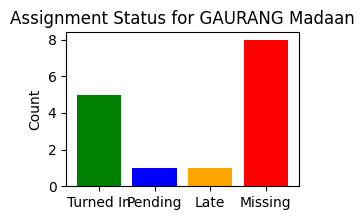

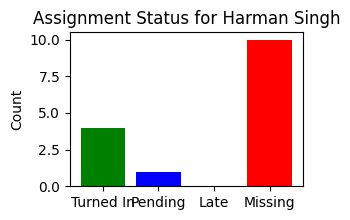

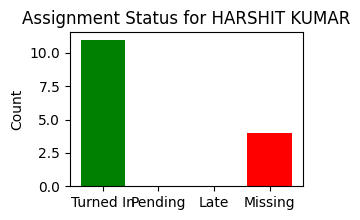

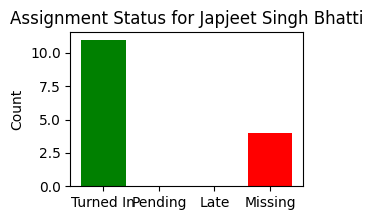

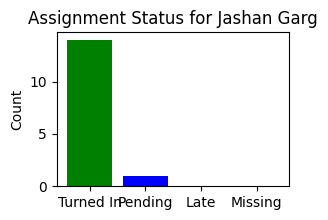

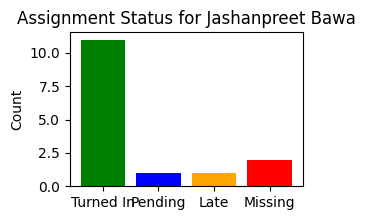

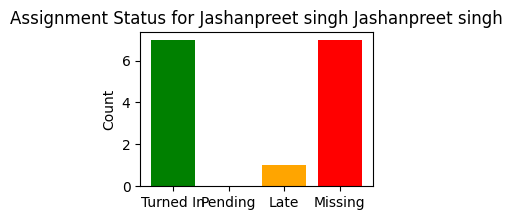

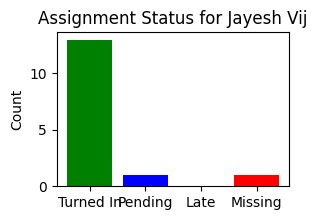

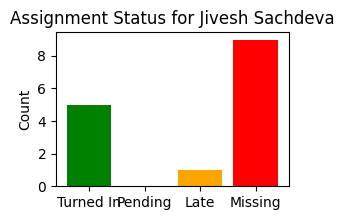

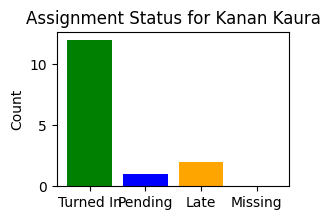

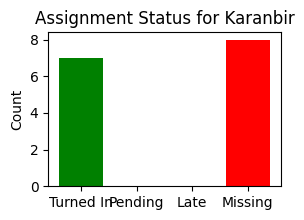

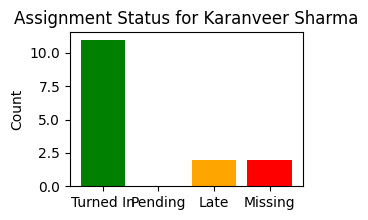

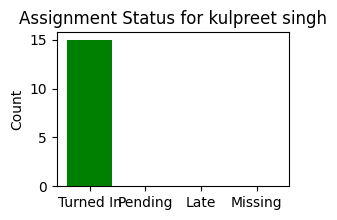

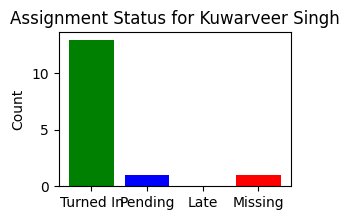

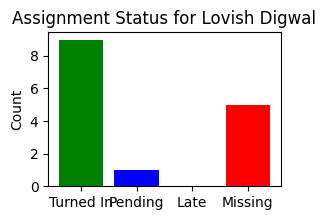

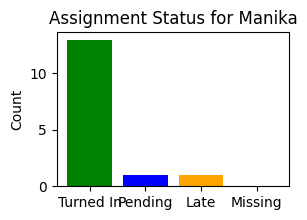

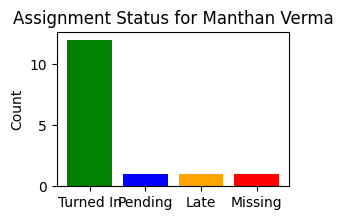

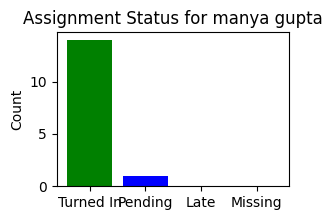

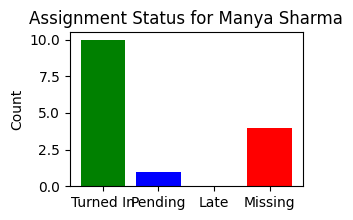

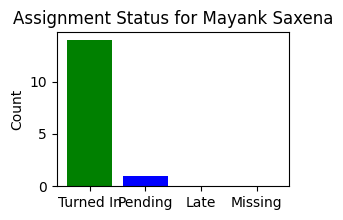

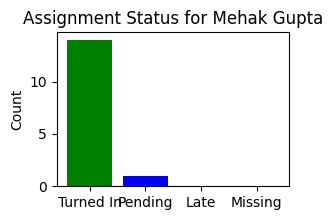

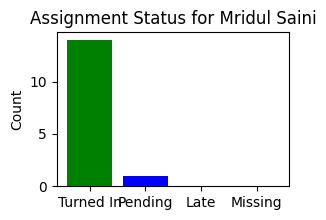

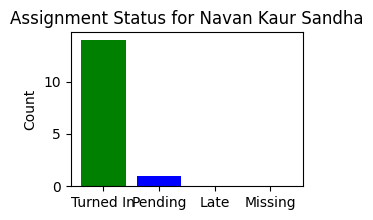

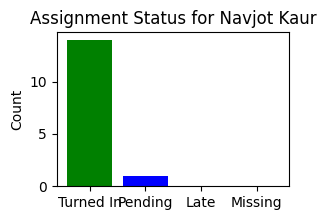

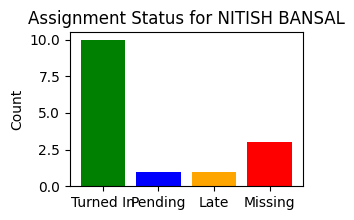

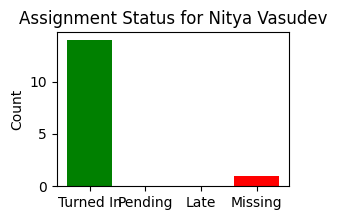

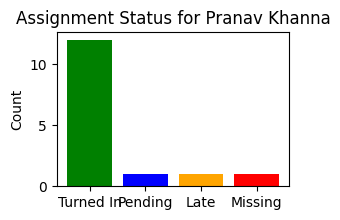

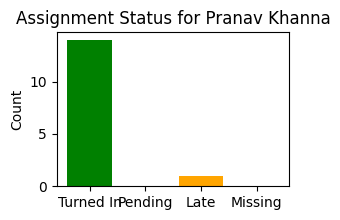

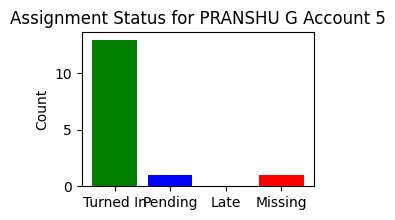

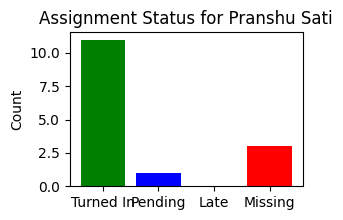

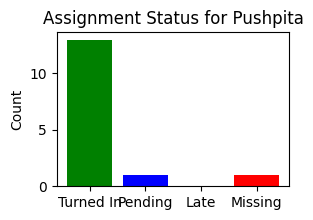

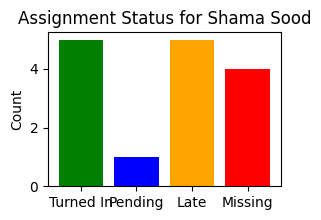

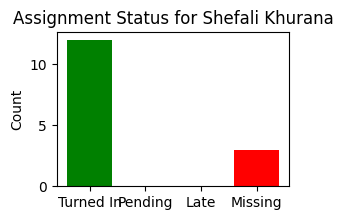

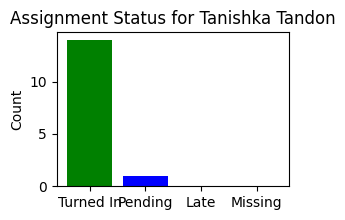

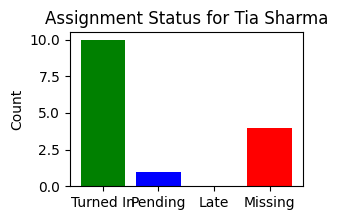

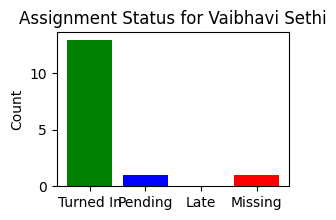

In [ ]:
for i, row in student_status.iterrows():
    plt.figure(figsize=(3,2))
    plt.bar(["Turned In","Pending","Late","Missing"],
            [row["TurnedIn_Count"], row["Pending_Count"], row["Late_Count"], row["Missing_Count"]],
            color=["green","blue","orange","red"])

    plt.title(f"Assignment Status for {row['Name']}")
    plt.ylabel("Count")
    plt.show()